In [1]:
import sys
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336')
import jax
jax.config.update('jax_num_cpu_devices', 6)
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'cpu')
import scipy.constants as C
from EM_analyzer.Spectral_Maxwell.Generate_Fields.Gaussian_beam_2D import Gaussian_Beam_2D
import jax.numpy as jnp
from plot.plot_2D import plot_2D_field

6
6
[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5)]
6
[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5)]


In [2]:
laser_lambda = 0.8*C.micron		# Laser wavelength, unit:m
laser_f0=1/laser_lambda   #unit: m^-1
laser_k0=2*C.pi*laser_f0
laser_omega0=(2*C.pi*C.speed_of_light)/(laser_lambda)
laser_period=laser_lambda/C.speed_of_light
laser_Bc=(C.m_e*laser_omega0)/(C.elementary_charge)   #unit: T. 1.338718e+04T for 800nm laser
laser_Ec=laser_Bc*C.speed_of_light   #unit: V/m. 4.013376e+12V/m for 800nm laser
laser_a0 = 50		# Laser field strength
laser_amp=laser_a0*laser_Ec   #unit: V/m
laser_FWHM=8*C.femto   #The full width at half maximum of the intensity.
laser_tau=laser_FWHM/jnp.sqrt(2*jnp.log(2)) 
laser_w0_lambda= 5
laser_zR_lambda=C.pi*laser_w0_lambda**2
laser_w0=laser_w0_lambda*laser_lambda
laser_zR=laser_zR_lambda*laser_lambda

In [3]:
gaussian_beam = Gaussian_Beam_2D(
    wavelength=laser_lambda,
    w0_lambda=laser_w0_lambda,
    phi_pol=0.0,
    phi_cep=0.0,
    a0=laser_a0,
    r_resolution=20,
    k_resolution=40,
)

resolution: λ0/dx=20.0, k0/dkx=40.04999999999832
Initial angular spectrum at z=0 plane:
Initial angular spectrum shape: (3, 801)
Initialized angular spectrum shape: EKx0: (801, 1), EKy0: (801, 1), EKz0: (801, 1)
kx_coordinate size: 801, ky_coordinate size: 1


In [4]:
EB_evolution_dict=gaussian_beam.get_pulse(
    FWHM_time=laser_FWHM,
    #time_shift=-max(2.5*laser_w0/C.speed_of_light,2*laser_FWHM), 
    #theta=jnp.radians(45)
    )

Propagating to 361 z planes.
Ek_all_z shape: (3, 801, 1, 361), Bk_all_z shape: (3, 801, 1, 361)
E_all_z shape: (3, 801, 1, 361), B_all_z shape: (3, 801, 1, 361)
Max relative divergence error: L*|∇·F|/|F| = 1.02e-02
Initial Field divergence check passed: relative L*|∇·F|/|F| = 0.01016344464881406 <= 0.5
Max relative divergence error: L*|∇·F|/|F| = 0.00e+00
Initial Field divergence check passed: relative L*|∇·F|/|F| = 0.0 <= 0.5


figure size= [28.22853186 14.        ] inch
ax_main position= Bbox(x0=0.15941317894117074, y0=0.10714285714285714, x1=0.7874490947451056, y1=0.6785714285714285)


{'fig': <Figure size 2822.85x1400 with 5 Axes>,
 'ax_main': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$\\frac{y}{\\lambda_0}$'>,
 'ax_panel_top': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>,
 'ax_panel_left': <Axes: xlabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$', ylabel='$\\frac{y}{\\lambda_0}$'>,
 'ax_cbar': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x14f84cec16a0>}

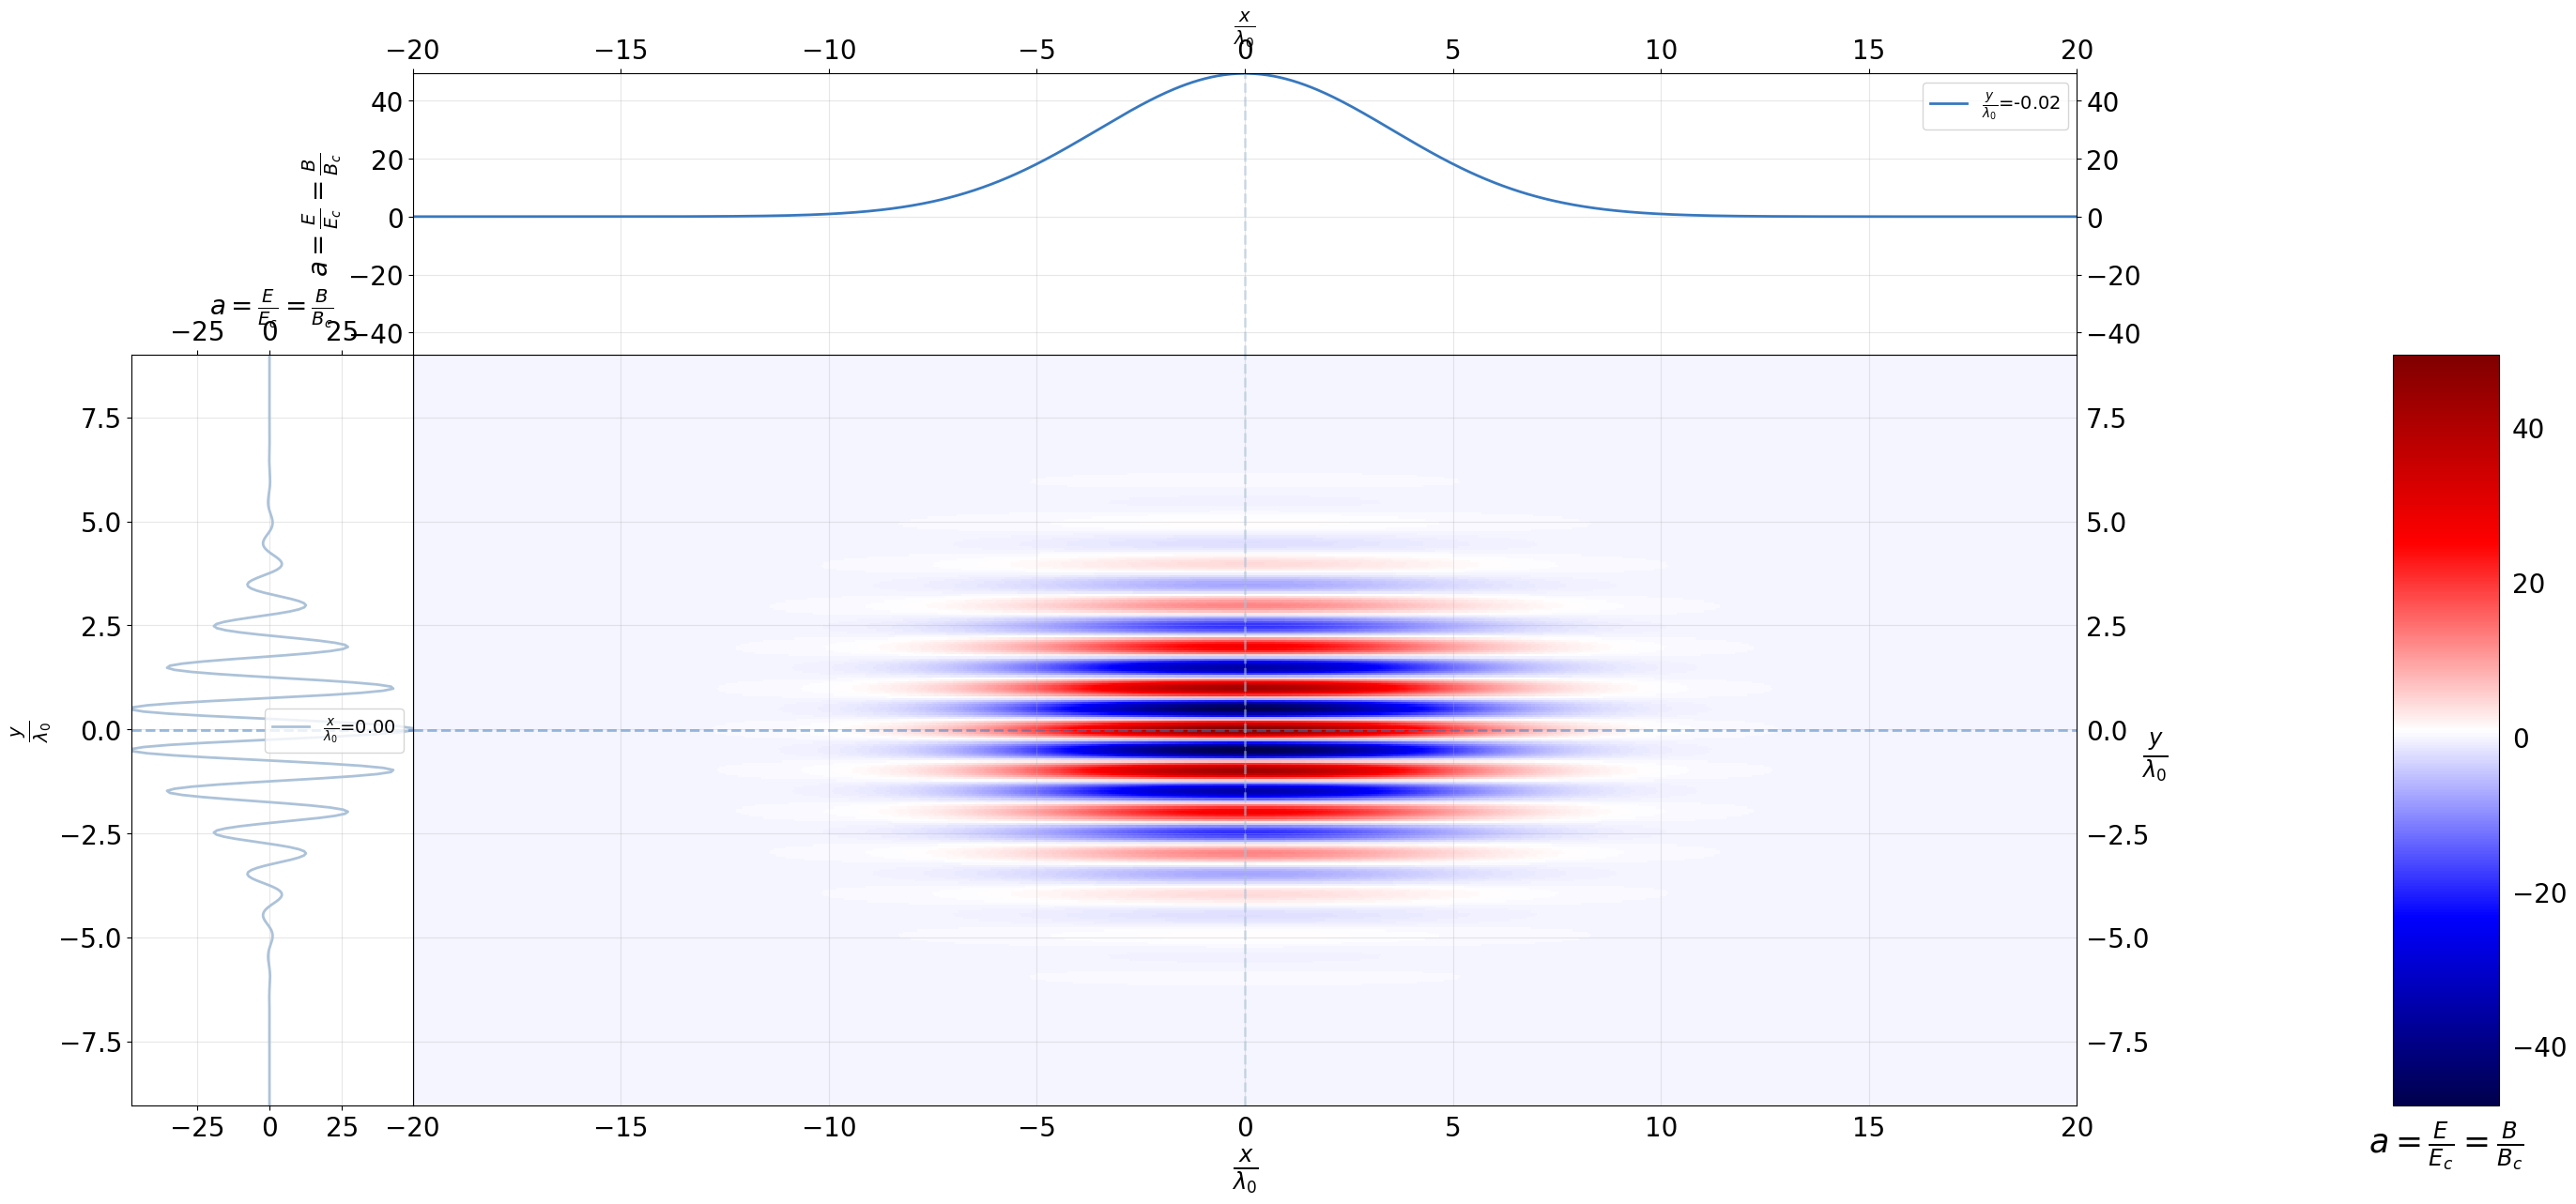

In [5]:
plot_2D_field(
    field=EB_evolution_dict["E"][0,:,0,:]/laser_Ec,
    x_coordinate=EB_evolution_dict["x_coordinate"]/laser_lambda,
    y_coordinate=EB_evolution_dict["z_coordinate"]/laser_lambda,
)